## 1. Import Libraries and Data


In [2]:
from dotenv import load_dotenv
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

/Users/daniellechoi/Documents/projects/ev-purchase-predict/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()
KAGGLE_API_KEY = os.getenv("KAGGLE_API_KEY")

In [4]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e9')

print("Path to competition files:", path)

Path to competition files: /Users/daniellechoi/.cache/kagglehub/competitions/playground-series-s6e9


In [5]:
%mv /Users/daniellechoi/.cache/kagglehub/competitions/playground-series-s6e9 /Users/daniellechoi/Documents/projects/ev-purchase-predict/data


mv: rename /Users/daniellechoi/.cache/kagglehub/competitions/playground-series-s6e9 to /Users/daniellechoi/Documents/projects/ev-purchase-predict/data/playground-series-s6e9: Directory not empty


In [6]:
sample_submission = pd.read_csv("data/playground-series-s6e9/sample_submission.csv")
test_data = pd.read_csv("data/playground-series-s6e9/test.csv")
train_data = pd.read_csv("data/playground-series-s6e9/train.csv")

## 2. EDA

In [7]:
print("Test data shape:", test_data.shape)
print("Train data shape:", train_data.shape)
print("Test:Train ratio:", test_data.shape[0] / train_data.shape[0])

Test data shape: (286571, 14)
Train data shape: (668665, 15)
Test:Train ratio: 0.4285718558620535


In [8]:
train_data.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


<Axes: xlabel='Will_Buy_EV'>

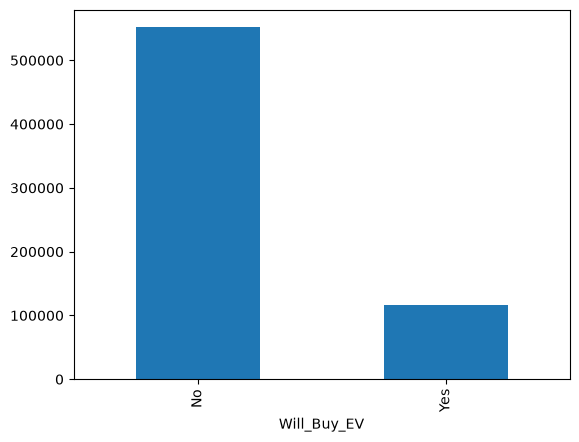

In [9]:
train_data['Will_Buy_EV'].value_counts().plot(kind='bar')

In [10]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [11]:
train_data.duplicated().sum()

np.int64(0)

*   No missing data
*   No duplicates
*   7 numerical columns (excluding id) and 6 categorical columns (excluding y value)

### Categorical Data

In [12]:
train_data.iloc[:,8:14].nunique(axis=0)

Gender                    3
City_Type                 3
Current_Car_Type          4
Home_Charging_Possible    2
Subsidy_Available         2
Range_Anxiety_Level       3
dtype: int64

* One-hot-encoding available

In [13]:
print("Gender: ",train_data['Gender'].unique())
print("City_Type: ",train_data['City_Type'].unique())
print("Current_Car_Type: ",train_data['Current_Car_Type'].unique())
print("Home_Charging_Possible: ",train_data['Home_Charging_Possible'].unique())
print("Subsidy_Available: ",train_data['Subsidy_Available'].unique())
print("Range_Anxiety_Level: ",train_data['Range_Anxiety_Level'].unique())

Gender:  <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
City_Type:  <StringArray>
['Suburban', 'Rural', 'Urban']
Length: 3, dtype: str
Current_Car_Type:  <StringArray>
['Sedan', 'SUV', 'Hatchback', 'Truck']
Length: 4, dtype: str
Home_Charging_Possible:  <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Subsidy_Available:  <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Range_Anxiety_Level:  <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str


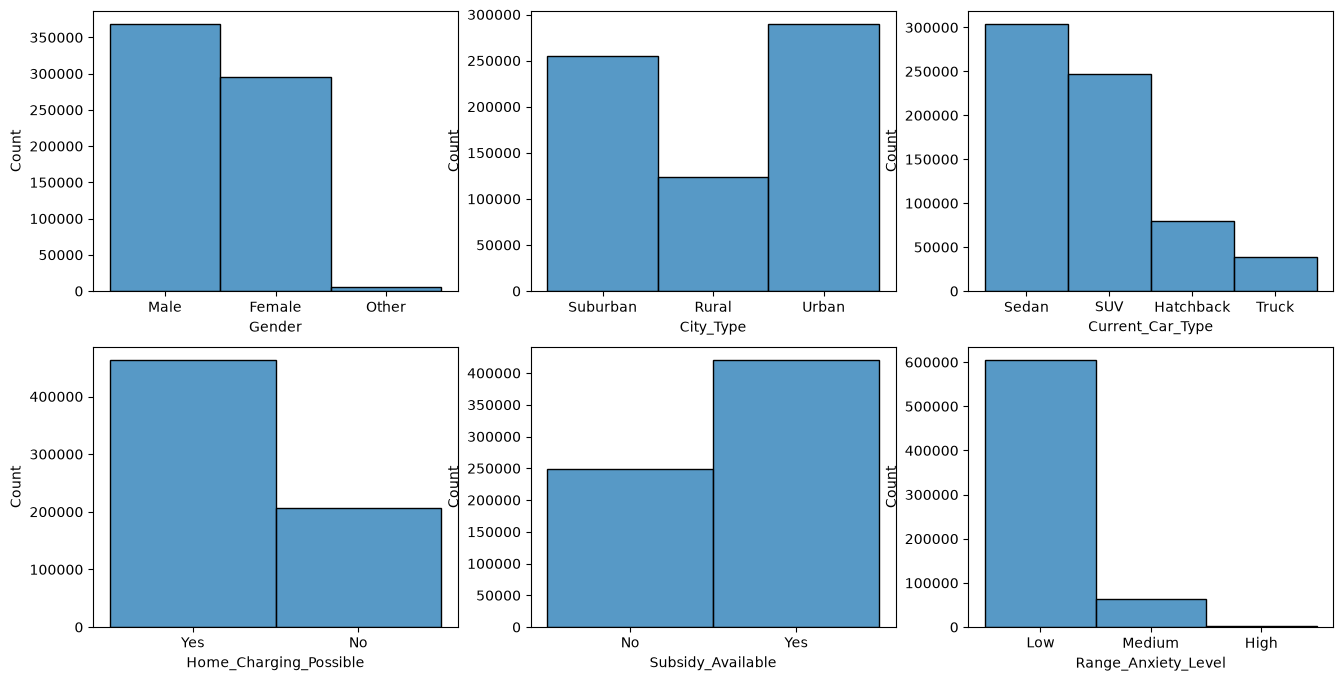

In [14]:
plt.figure(figsize = (16,8))
plt.subplot(2,3,1)
sns.histplot(train_data['Gender'])
plt.subplot(2,3,2)
sns.histplot(train_data['City_Type'])
plt.subplot(2,3,3)
sns.histplot(train_data['Current_Car_Type'])
plt.subplot(2,3,4)
sns.histplot(train_data['Home_Charging_Possible'])
plt.subplot(2,3,5)
sns.histplot(train_data['Subsidy_Available'])
plt.subplot(2,3,6)
sns.histplot(train_data['Range_Anxiety_Level'])
plt.show()

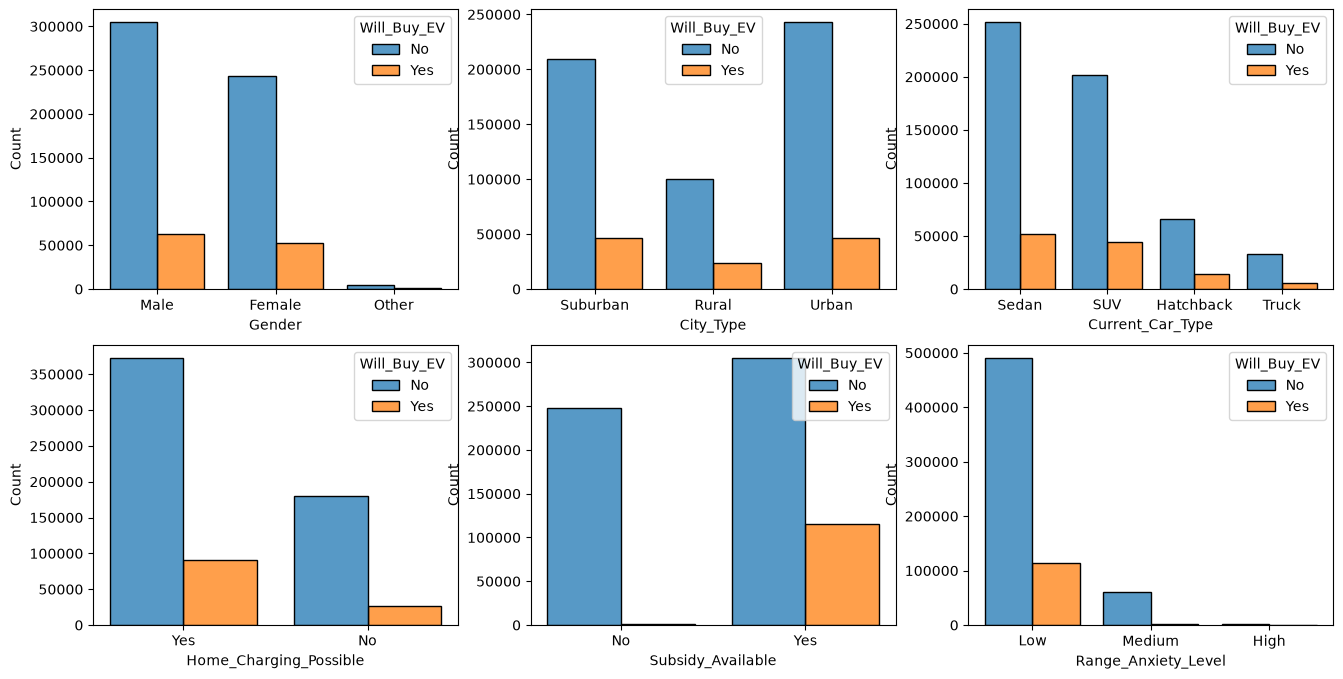

In [29]:
plt.figure(figsize = (16,8))
plt.subplot(2,3,1)
sns.histplot(data=train_data, x='Gender', hue='Will_Buy_EV', multiple='dodge',shrink=0.8)
plt.subplot(2,3,2)
sns.histplot(data=train_data, x='City_Type', hue='Will_Buy_EV', multiple='dodge',shrink=0.8)
plt.subplot(2,3,3)
sns.histplot(data=train_data, x='Current_Car_Type', hue='Will_Buy_EV', multiple='dodge',shrink=0.8)
plt.subplot(2,3,4)
sns.histplot(data=train_data, x='Home_Charging_Possible', hue='Will_Buy_EV', multiple='dodge',shrink=0.8)
plt.subplot(2,3,5)
sns.histplot(data=train_data, x='Subsidy_Available', hue='Will_Buy_EV', multiple='dodge',shrink=0.8)
plt.subplot(2,3,6)
sns.histplot(data=train_data, x='Range_Anxiety_Level', hue='Will_Buy_EV', multiple='dodge',shrink=0.8)
plt.show()

### Numerical Data

In [53]:
train_data.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.000000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.103211,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.000000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.000000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.000000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.000000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.000000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [54]:
train_data.corr(numeric_only=True)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
id,1.000000,0.001324,-0.000436,-0.001042,0.000396,0.002326,0.000897,-0.000073
Age,0.001324,1.000000,-0.004559,-0.006538,-0.002028,-0.004133,-0.005855,-0.003703
Annual_Income_USD,-0.000436,-0.004559,1.000000,0.007994,-0.000154,-0.008646,-0.002770,0.076405
Daily_Commute_km,-0.001042,-0.006538,0.007994,1.000000,0.002722,0.045158,0.034986,-0.018868
Number_of_Cars_Owned,0.000396,-0.002028,-0.000154,0.002722,1.000000,0.008495,0.008611,-0.000579
Charging_Stations_Near_Home,0.002326,-0.004133,-0.008646,0.045158,0.008495,1.000000,0.511134,-0.011332
Charging_Stations_Near_Work,0.000897,-0.005855,-0.002770,0.034986,0.008611,0.511134,1.000000,-0.007833
Environmental_Concern_Level,-0.000073,-0.003703,0.076405,-0.018868,-0.000579,-0.011332,-0.007833,1.000000


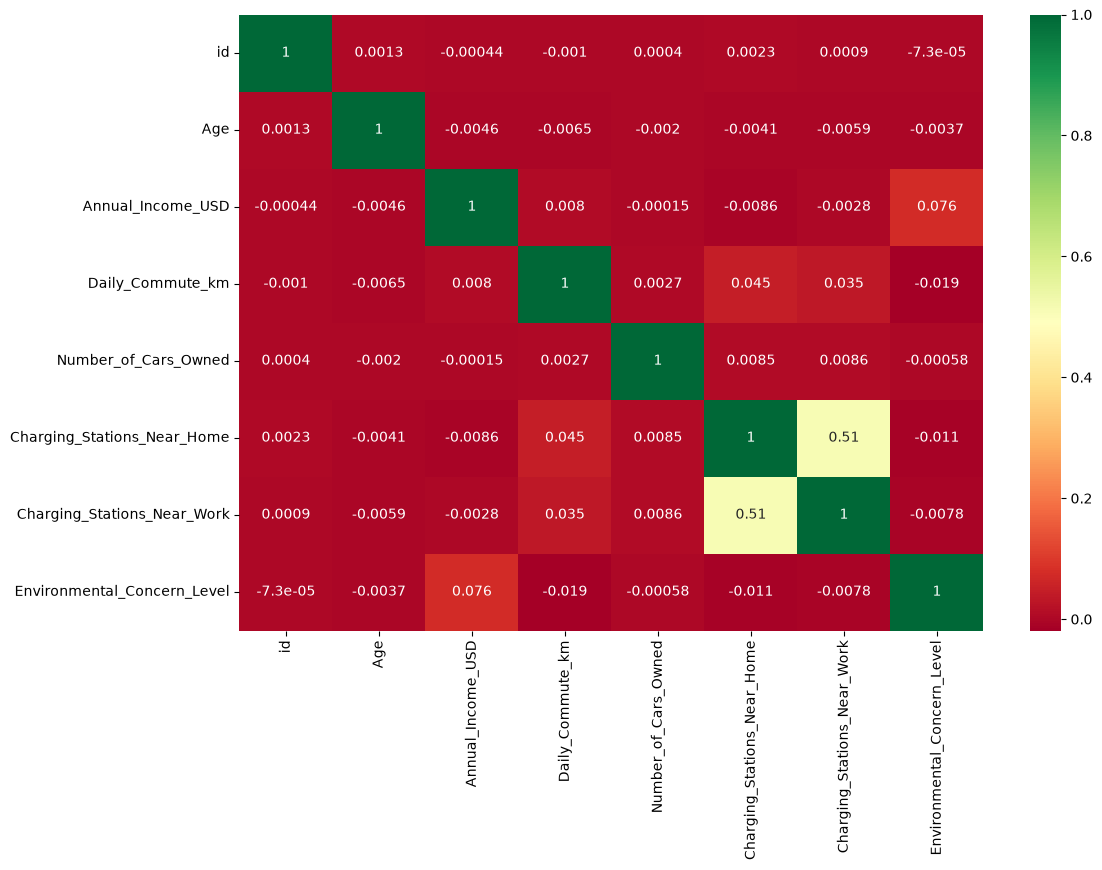

In [55]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap='RdYlGn')
plt.show()

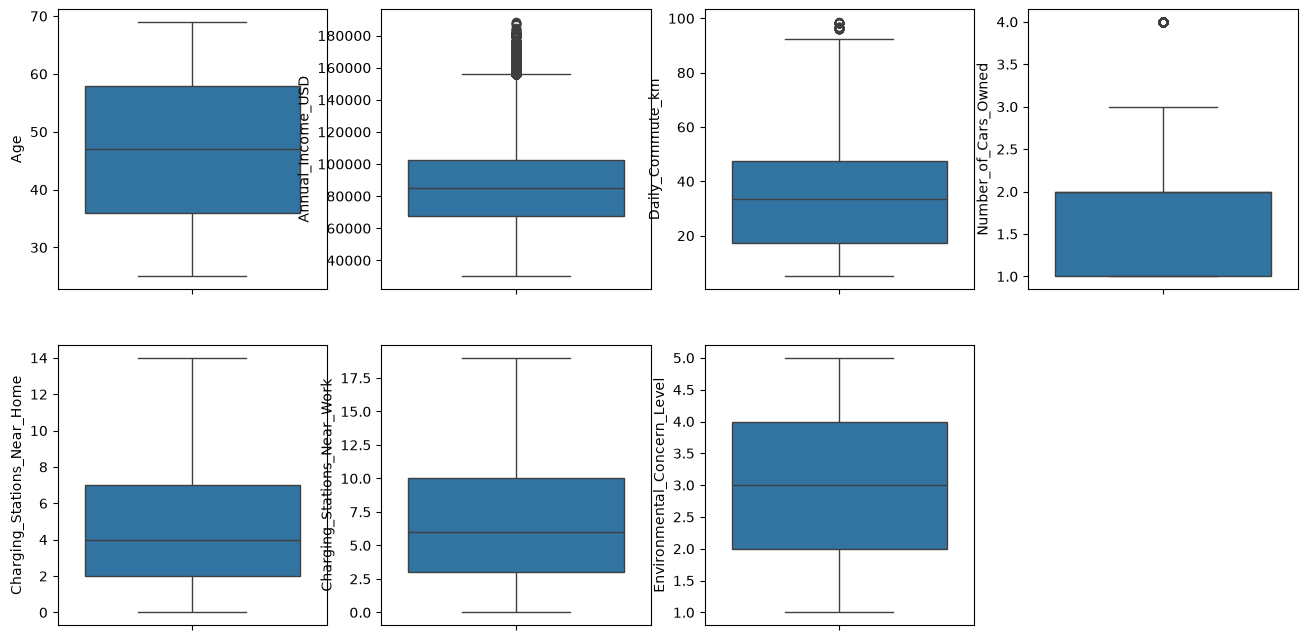

In [58]:
plt.figure(figsize = (16,8))
plt.subplot(2,4,1)
sns.boxplot(train_data['Age'])
plt.subplot(2,4,2)
sns.boxplot(train_data['Annual_Income_USD'])
plt.subplot(2,4,3)
sns.boxplot(train_data['Daily_Commute_km'])
plt.subplot(2,4,4)
sns.boxplot(train_data['Number_of_Cars_Owned'])
plt.subplot(2,4,5)
sns.boxplot(train_data['Charging_Stations_Near_Home'])
plt.subplot(2,4,6)
sns.boxplot(train_data['Charging_Stations_Near_Work'])
plt.subplot(2,4,7)
sns.boxplot(train_data['Environmental_Concern_Level'])
plt.show()

In [ ]:
# Change the target variable to binary values for modeling
train_data['Will_Buy_EV'] = train_data['Will_Buy_EV'].replace({'No': 0, 'Yes': 1}).astype(int)

In [75]:
train_data.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


In [76]:
train_data.corr(numeric_only=True)['Will_Buy_EV'].sort_values(ascending=False)

Will_Buy_EV                    1.000000
Environmental_Concern_Level    0.464079
Annual_Income_USD              0.225729
Number_of_Cars_Owned           0.003896
id                            -0.000013
Age                           -0.007450
Charging_Stations_Near_Work   -0.012229
Charging_Stations_Near_Home   -0.016353
Daily_Commute_km              -0.045866
Name: Will_Buy_EV, dtype: float64

* Environmental_Concern_Level and Annual_Income_USD have the biggest correlations.

### Compare training set and testing set

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Annual_Income_USD'}>],
       [<Axes: title={'center': 'Daily_Commute_km'}>,
        <Axes: title={'center': 'Number_of_Cars_Owned'}>,
        <Axes: title={'center': 'Charging_Stations_Near_Home'}>],
       [<Axes: title={'center': 'Charging_Stations_Near_Work'}>,
        <Axes: title={'center': 'Environmental_Concern_Level'}>,
        <Axes: >]], dtype=object)

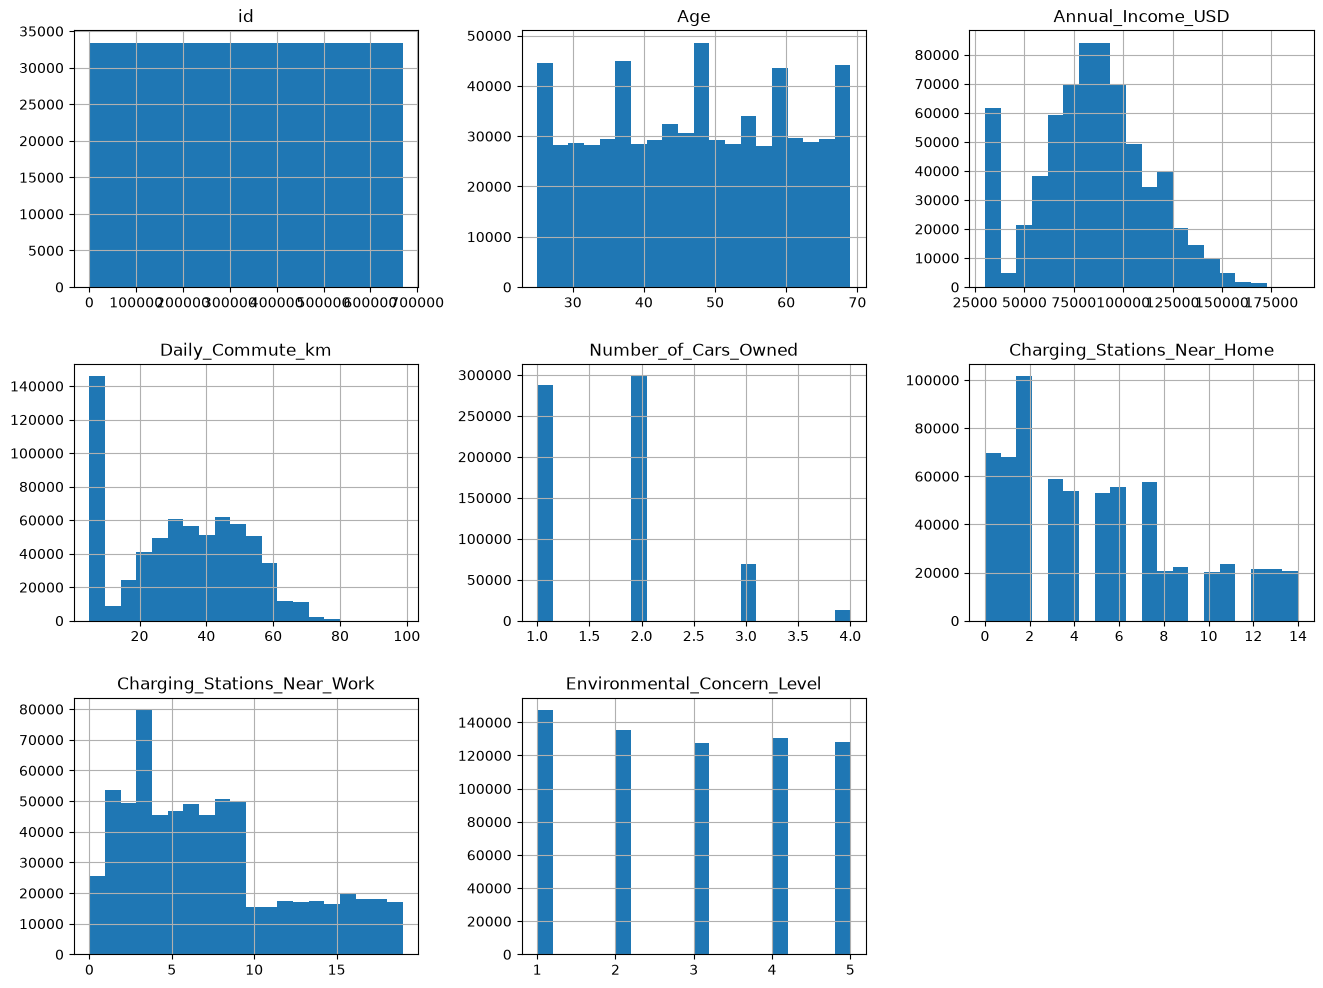

In [33]:
train_data.hist(bins=20, figsize=(16, 12))

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Annual_Income_USD'}>],
       [<Axes: title={'center': 'Daily_Commute_km'}>,
        <Axes: title={'center': 'Number_of_Cars_Owned'}>,
        <Axes: title={'center': 'Charging_Stations_Near_Home'}>],
       [<Axes: title={'center': 'Charging_Stations_Near_Work'}>,
        <Axes: title={'center': 'Environmental_Concern_Level'}>,
        <Axes: >]], dtype=object)

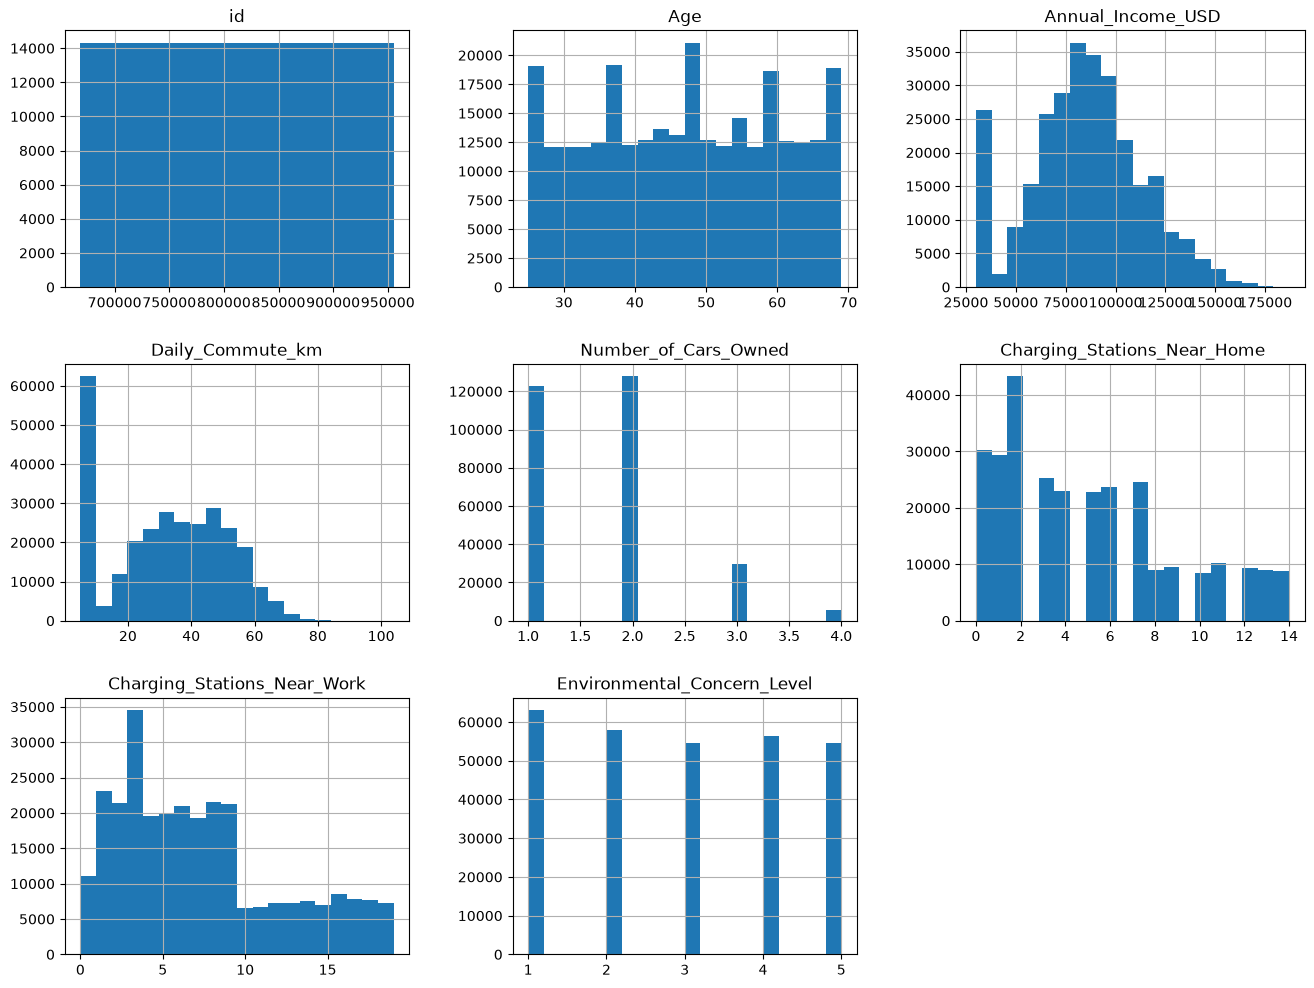

In [31]:
test_data.hist(bins=20, figsize=(16, 12))

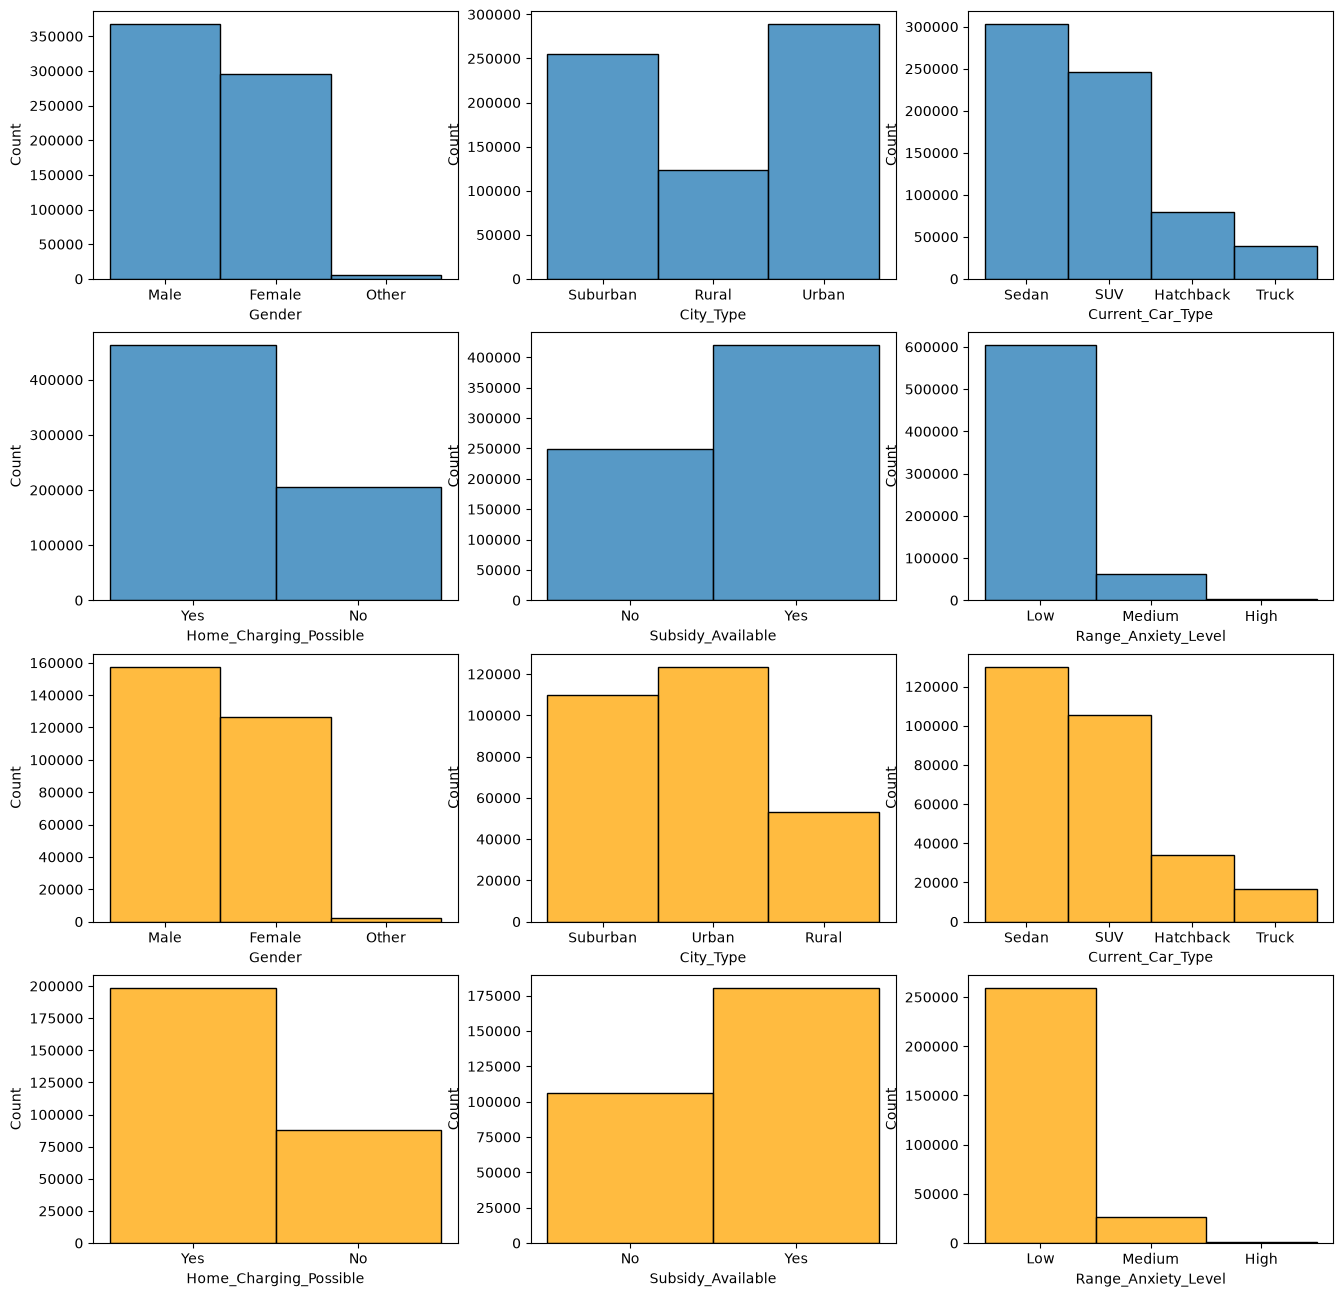

In [36]:
plt.figure(figsize = (16,16))
plt.subplot(4,3,1)
sns.histplot(train_data['Gender'])
plt.subplot(4,3,2)
sns.histplot(train_data['City_Type'])
plt.subplot(4,3,3)
sns.histplot(train_data['Current_Car_Type'])
plt.subplot(4,3,4)
sns.histplot(train_data['Home_Charging_Possible'])
plt.subplot(4,3,5)
sns.histplot(train_data['Subsidy_Available'])
plt.subplot(4,3,6)
sns.histplot(train_data['Range_Anxiety_Level'])
plt.subplot(4,3,7)
sns.histplot(test_data['Gender'], color='orange')
plt.subplot(4,3,8)
sns.histplot(test_data['City_Type'], color='orange')
plt.subplot(4,3,9)
sns.histplot(test_data['Current_Car_Type'], color='orange')
plt.subplot(4,3,10)
sns.histplot(test_data['Home_Charging_Possible'], color='orange')
plt.subplot(4,3,11)
sns.histplot(test_data['Subsidy_Available'], color='orange')
plt.subplot(4,3,12)
sns.histplot(test_data['Range_Anxiety_Level'], color='orange')
plt.show()

* The distribution of the train dataset and test dataset are nearly identical.

## Attempt before Feature Engineering

## Feature Engineering

## Data Preprocessing

## Splitting Dataset

## Model Training